In [3]:
import os
import sys
sys.path.append(os.path.abspath("../../"))

# Importa as bibliotecas necessárias
import pandas as pd
import matplotlib.pyplot as plt
from classes.neural_networks.training.train_linear_regression import train_and_evaluate, load_data

# Define os parâmetros
csv_path = "../../datasets/b3_dados/processed/acoes_concat.csv"
window = 3

# Carrega os dados para obter as datas
df = load_data(csv_path)
df.sort_values("Date", inplace=True)
dates = df['Date'].values

ModuleNotFoundError: No module named 'main'

In [3]:
target = "VALE3"


Métricas de Treino:
MSE: 0.1510
RMSE: 0.3886
MAE: 0.2947
R2: 0.9945

Métricas de Validação:
MSE: 0.4229
RMSE: 0.6503
MAE: 0.5032
R2: 0.9682

Métricas de Teste:
MSE: 1.5617
RMSE: 1.2497
MAE: 0.8785
R2: 0.9953
Parâmetros do modelo: [ 0.00151156  1.05339531 -0.08223169  0.02593945]
Métricas de Treino: {'MSE': 0.15098921877210425, 'RMSE': 0.3885733119658429, 'MAE': 0.29467344694685704, 'R2': 0.9944743940789923}
Métricas de Validação: {'MSE': 0.42293312295134045, 'RMSE': 0.6503330861576554, 'MAE': 0.5031925743127899, 'R2': 0.9682313126892639}
Métricas de Teste: {'MSE': 1.5617392592556514, 'RMSE': 1.2496956666547465, 'MAE': 0.8785220192633858, 'R2': 0.9952868738400295}


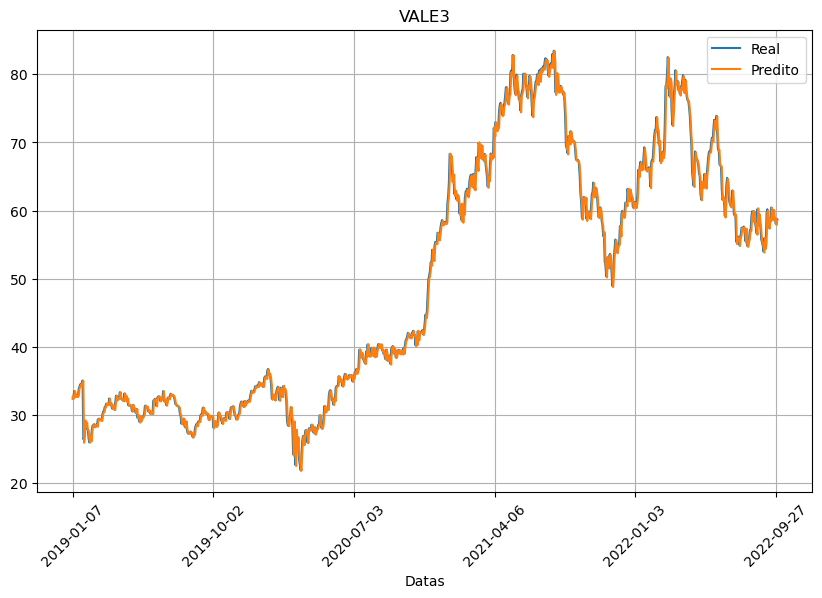

In [4]:

# Chama a função para treinar e avaliar o modelo
model, theta, train_metrics, val_metrics, test_metrics, y_test, test_predictions = train_and_evaluate(csv_path, target, window)

# Exibe os parâmetros do modelo e as métricas de treino, validação e teste
print("Parâmetros do modelo:", theta)
print("Métricas de Treino:", train_metrics)
print("Métricas de Validação:", val_metrics)
print("Métricas de Teste:", test_metrics)

# Visualiza os resultados
plt.figure(figsize=(10, 6))
plt.plot(y_test, label='Real')
plt.plot(test_predictions, label='Predito',)

# Adiciona as datas no eixo x
num_dates = len(y_test)
step = num_dates // 5  # Define o intervalo para 5 datas
plt.xticks(ticks=range(0, num_dates, step), labels=dates[-num_dates::step], rotation=45)

plt.title(target)
plt.xlabel('Datas')
plt.grid(True)
plt.legend()
plt.show()


Métricas de Treino:
MSE: 0.0034
RMSE: 0.0584
MAE: 0.0404
R2: 0.9902

Métricas de Validação:
MSE: 0.0041
RMSE: 0.0639
MAE: 0.0450
R2: 0.9848

Métricas de Teste:
MSE: 0.0093
RMSE: 0.0966
MAE: 0.0707
R2: 0.9908

Métricas de Treino:
MSE: 0.1000
RMSE: 0.3162
MAE: 0.1807
R2: 0.9958

Métricas de Validação:
MSE: 0.3826
RMSE: 0.6185
MAE: 0.4641
R2: 0.9596

Métricas de Teste:
MSE: 0.8560
RMSE: 0.9252
MAE: 0.6730
R2: 0.9769

Métricas de Treino:
MSE: 0.0506
RMSE: 0.2249
MAE: 0.1641
R2: 0.9897

Métricas de Validação:
MSE: 0.0456
RMSE: 0.2135
MAE: 0.1608
R2: 0.9640

Métricas de Teste:
MSE: 0.3380
RMSE: 0.5813
MAE: 0.4042
R2: 0.9824


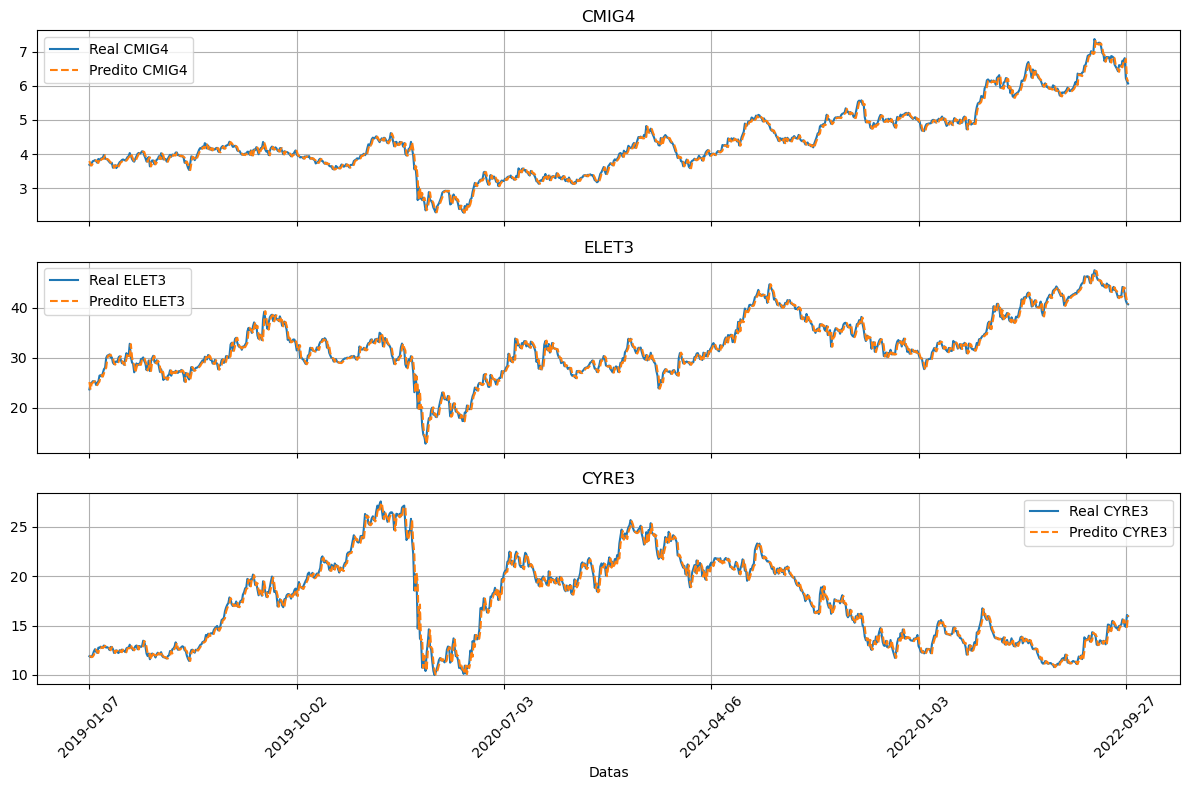

In [5]:
# Lista de ações a serem analisadas
acoes = ["CMIG4", "ELET3", "CYRE3",]

# Dicionário para armazenar os resultados
resultados = {}

# Treina e avalia o modelo para cada ação
for acao in acoes:
    model, theta, train_metrics, val_metrics, test_metrics, y_test, test_predictions = train_and_evaluate(csv_path, acao, window)
    resultados[acao] = (y_test, test_predictions)

# Visualiza os resultados em subplots
fig, axes = plt.subplots(len(acoes), 1, figsize=(12, 8), sharex=True)

for i, acao in enumerate(acoes):
    y_test, test_predictions = resultados[acao]
    axes[i].plot(y_test, label=f'Real {acao}')
    axes[i].plot(test_predictions, label=f'Predito {acao}', linestyle='--')
    axes[i].set_title(acao)
    axes[i].legend()
    axes[i].grid(True)

# Adiciona as datas no eixo x do último subplot
num_dates = len(y_test)
step = num_dates // 5  # Define o intervalo para 5 datas
axes[-1].set_xticks(range(0, num_dates, step))
axes[-1].set_xticklabels(dates[-num_dates::step], rotation=45)

plt.xlabel('Datas')
plt.tight_layout()
plt.show()